# TODO 9.3.

- random sampling effect on RMSE
- induce missingness in sequence
- MAR assumption: generating coverage from the mag. field
- run KNN 

In [1]:
import numpy as np
import pandas as pd

from pathlib import Path
from itertools import product
from sklearn.impute import KNNImputer
from numpy.lib.stride_tricks import sliding_window_view
from IPython.display import clear_output

from aipad.pad_imputation import (
    make_train_test, form_test_matrices, calculate_scores,
    plot_results, save_results, pad_histogram)

from aipad.padimputer import PADImputer
from aipad.spacecrafts import SoloConstants, WindConstants
from aipad.datahandler import WindDataHandler

solo = SoloConstants()
wind = WindConstants()

In [2]:
bins = 8
time_avg_min = 1
avg_bin_dir = f"{time_avg_min}min_{bins}bins"

load_path = Path("./data/intensities") / avg_bin_dir
cov_path = Path("./data/coverages") / avg_bin_dir
plot_path = Path(f"./plots/")

plot_path.mkdir(exist_ok=True)

In [3]:
data_dict = WindDataHandler.load_file("wind_1min_8bins.h5")

### Simple imputation strategies: row/column mean, average of forward and backward fill, linear interpolation


In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.dates import HourLocator, DateFormatter

def target_from_prediction(true, reduced, imputed):
    pred = np.where((np.isnan(reduced)
                    & np.isfinite(true)
                    & np.meshgrid(np.isfinite(reduced).any(axis=1), np.arange(0, reduced.shape[1]),
                                  indexing="ij")[0]),
                    imputed, np.nan)
    target = np.where(np.isfinite(pred), true, np.nan)
    return target, pred

def plot_results(t, pa, I_data, true, reduced, imputed, score: str,
                 sc: WindConstants, cov_sc: SoloConstants,
                 save_plot=True, save_path=None) -> None:
    
    target, pred = target_from_prediction(true, reduced, imputed)

    # Score over whole 12 hrs
    total_score = calculate_scores(target, pred, score)

    true_miss_percent = np.sum(np.where(np.isnan(true), 1, 0)) \
        / (true.shape[0] * true.shape[1]) * 100
    reduced_miss_percent = np.sum(np.where(np.isnan(reduced), 1, 0)) \
        / (reduced.shape[0] * reduced.shape[1]) * 100

    X, Y = np.meshgrid(t, pa, indexing="ij")

    norm = LogNorm(np.nanmin(true), np.nanmax(true))
    diff_norm = LogNorm(1e-3, 1e3)

    fig, axs = plt.subplots(nrows=8, figsize=(16, 32), sharex=True)

    # for b in range(B_data.values.shape[1]):
    #     axs[0].plot(t, B_data[:, b], label=B_data.columns[b])

    for i in range(I_data.shape[1]):
        axs[1].plot(t, I_data[:, i], label=sc.sectors[i])

    # axs[0].set_title("Magnetic field")
    # axs[0].legend(loc="upper right")
    axs[0].xaxis.set_major_locator(HourLocator(range(12)))
    axs[0].xaxis.set_major_formatter(DateFormatter("%d %b\n%H:%M"))
    axs[1].set_title("Intensities")
    axs[1].set_yscale("log")
    axs[1].legend(loc="upper right")

    axs[2].pcolormesh(X, Y, true, norm=norm, cmap="inferno")
    axs[2].set_title(f"{sc.name.upper()} PAD, total {true_miss_percent:.2f} % missing")

    axs[3].pcolormesh(X, Y, reduced, norm=norm, cmap="inferno")
    axs[3].set_title(f"{sc.name.upper()} PAD w/ reduction, {reduced_miss_percent:.2f} % missing")

    axs[4].pcolormesh(X, Y, imputed, norm=norm, cmap="inferno")
    axs[4].set_title("Imputed values")

    axs[5].pcolormesh(X, Y, pred, norm=norm, cmap="inferno")
    axs[5].set_title("Predicted values")

    axs[6].pcolormesh(X, Y, target, norm=norm, cmap="inferno")
    axs[6].set_title(f"Target values (RMSE = {total_score})")

    diff = np.abs(target - pred)

    mesh = axs[7].pcolormesh(X, Y, diff, norm=diff_norm)
    axs[7].set_title("Absolute difference")
    axins = inset_axes(axs[7], width="100%", height="100%", loc="center",
                       bbox_to_anchor=(1.01, 0, 0.03, 1), bbox_transform=axs[7].transAxes,
                       borderpad=0.2)
    fig.colorbar(mesh, cax=axins, orientation="vertical")

    if save_plot:
        plt.savefig(save_path)
        plt.close()

    else:
        plt.show()

TypeError: unhashable type: 'numpy.ndarray'

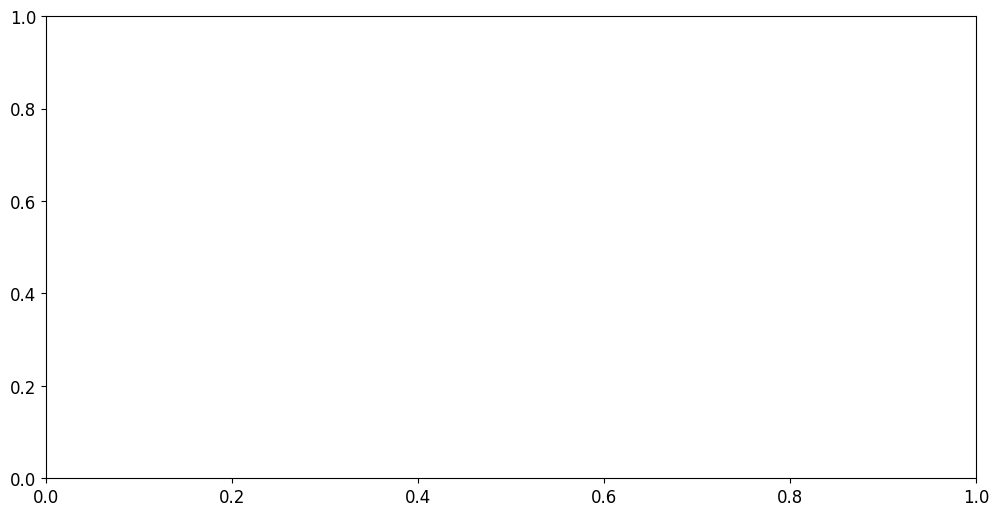

In [7]:
imputer = PADImputer()
I_data = data_dict["Intensities"][0]
B_data = data_dict["MagField"][0]
pa = data_dict["PitchAngle"][0]
t = data_dict["Epoch"][0]

ind = pd.MultiIndex.from_product([wind.sectors, ["min", "center", "max"]])
cov = pd.DataFrame(data_dict["Coverage"][0], index=t, columns=ind)

true = pad_histogram(wind, I_data, cov, bins=8)
X, Y = np.meshgrid(t, pa, indexing="ij")
fig, ax = plt.subplots(figsize=(12, 6))
plt.pcolormesh(X, Y, true)

In [ ]:
np.datetime_data

array([b'2012-01-02T13:37:40.771000000', b'2012-01-02T13:38:40.771000000',
       b'2012-01-02T13:39:40.771000000', b'2012-01-02T13:40:40.771000000',
       b'2012-01-02T13:41:40.771000000', b'2012-01-02T13:42:40.771000000',
       b'2012-01-02T13:43:40.771000000', b'2012-01-02T13:44:40.771000000',
       b'2012-01-02T13:45:40.771000000', b'2012-01-02T13:46:40.771000000',
       b'2012-01-02T13:47:40.771000000', b'2012-01-02T13:48:40.771000000',
       b'2012-01-02T13:49:40.771000000', b'2012-01-02T13:50:40.771000000',
       b'2012-01-02T13:51:40.771000000', b'2012-01-02T13:52:40.771000000',
       b'2012-01-02T13:53:40.771000000', b'2012-01-02T13:54:40.771000000',
       b'2012-01-02T13:55:40.771000000', b'2012-01-02T13:56:40.771000000',
       b'2012-01-02T13:57:40.771000000', b'2012-01-02T13:58:40.771000000',
       b'2012-01-02T13:59:40.771000000', b'2012-01-02T14:00:40.771000000',
       b'2012-01-02T14:01:40.771000000', b'2012-01-02T14:02:40.771000000',
       b'2012-01-02T14:03

In [ ]:
imputer = PADImputer()
for method, axis in product(imputer._strategy_map.keys(), [0, 1]):
    print(f"Running simple imputation: method = {method}, axis = {axis}")
    imputer.method = method
    imputer.axis = axis

    mean_scores = {}
    fill_scores = {}
    interp_scores = {}

    for i in range(20):
        pa = data_dict["PitchAngle"][i]     
        reduced = data_dict["reduced_0.5"][i]
        true = pad_histo
        times = pd.to_datetime(pd.Series(data_dict["times"][0], dtype="str"))
        intensities = data_dict["intensities"][i]
        imputed = imputer.fit_transform(reduced)
        
        target_mean, pred_mean = target_from_prediction(true, reduced, imputed)
        print(f"Mean (angular):\t\t{calculate_scores(target_mean, pred_mean, "rmse"):.3f}")

        plot_results(times, pa, intensities, true, reduced, imputed, score="rmse", sc=wind, cov_sc=solo,
                    save_plot=True, save_path=f"./plots/{method}_imputer/results{i:03d}_{axis}.png")

Case  0
Mean (temporal):		80.109
Fill average (angular)	: 62.557
Fill average (temporal)	: 17.333
Lin. interp. (angular):	61.745
Lin. interp. (temporal):	16.542
Case  1
Mean (temporal):		2885.963
Fill average (angular)	: 1858.075
Fill average (temporal)	: 492.258
Lin. interp. (angular):	1793.061
Lin. interp. (temporal):	452.642
Case  2
Mean (temporal):		11175.930
Fill average (angular)	: 10018.992
Fill average (temporal)	: 2348.889
Lin. interp. (angular):	9846.658
Lin. interp. (temporal):	2123.328
Case  3
Mean (temporal):		5283.112
Fill average (angular)	: 3566.667
Fill average (temporal)	: 912.912
Lin. interp. (angular):	3465.146
Lin. interp. (temporal):	801.019
Case  4
Mean (temporal):		2216.186
Fill average (angular)	: 1390.655
Fill average (temporal)	: 501.938
Lin. interp. (angular):	1334.901
Lin. interp. (temporal):	432.873
Case  5
Mean (temporal):		152.030
Fill average (angular)	: 103.202
Fill average (temporal)	: 40.092
Lin. interp. (angular):	98.429
Lin. interp. (temporal):	37.

### KNNImputer

In [ ]:
neighbors = 5

model = KNNImputer(n_neighbors=neighbors, weights="distance", keep_empty_features=True)
model.fit(X_train_stacked)

In [ ]:
for j in range(0, len(y_test)):
    res = form_test_matrices(model, X_test[j], y_test[j])
    plot_results(model, res, "mse", I_test[j], sc=wind, cov_sc=solo, save_path=plot_path / f"results_{j}.png")

### KNNImputer CV (no blocks)

In [ ]:
from aipad.padimputer import PADImputer
import logging
import sys
filehandler = logging.FileHandler(filename="./logs/cv_results.log", encoding="utf-8")
streamhandler = logging.StreamHandler(sys.stdout)
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(message)s', datefmt='%m/%d/%Y %H:%M:%S', handlers=[filehandler, streamhandler], force=True)

path = Path("./knn_imputer_on_wind_5neighbors.csv")

def form_test_matrices(model: KNNImputer, X_test: np.ndarray, size_pct: float, seed: int) -> list:
    true = X_test
    rand_rows, rand_cols, true_values = select_true_points(X_test, size_pct, seed)
    test = np.copy(X_test)
    test[rand_rows, rand_cols] = np.nan
    
    pred_full = model.transform(test)
    pred_values = np.ravel(pred_full[rand_rows, rand_cols])

    return [true, test, pred_full, pred_values, true_values]

# neighbors = np.arange(0, 31, 5)
# neighbors[0] = 1
neighbors = 5
n_splits = 3
size_pct = 0.30

X_train_stacked = np.vstack(X_train)

model = KNNImputer(n_neighbors=neighbors, weights="distance", keep_empty_features=True)
        
model.fit(X_train_stacked)
        
scores = []

for j in range(20):
    true, test, pred_full, pred_values, true_values = form_test_matrices(model, X_test[j], size_pct, 123)
    score = calculate_scores(pred_values, true_values, "rmse")
    
    cols = ["event_dt", "miss_percent", "score", "scorer", "neighbors"]

    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        df = pd.DataFrame(columns=cols)

    row = [pd.to_datetime(meta[j], format="%Y%m%d-%H%M%S"),
           size_pct, score, "rmse", neighbors]

    df.loc[df.shape[0]] = row

    df.to_csv(path, index=False)
    logging.info(f"Score for test event {j}: {score}")
    clear_output()


In [ ]:
from aipad.padimputer import select_true_points, BinningImputator
import logging
import sys
filehandler = logging.FileHandler(filename="./logs/cv_results.log", encoding="utf-8")
streamhandler = logging.StreamHandler(sys.stdout)
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(message)s', datefmt='%m/%d/%Y %H:%M:%S', handlers=[filehandler, streamhandler], force=True)

path = Path("./binningimputer_on_wind_angular.csv")

def form_test_matrices(model: KNNImputer, X_test: np.ndarray, size_pct: float, seed: int) -> list:
    true = X_test
    rand_rows, rand_cols, true_values = select_true_points(X_test, size_pct, seed)
    test = np.copy(X_test)
    test[rand_rows, rand_cols] = np.nan
    
    pred_full = model.transform(test)
    pred_values = np.ravel(pred_full[rand_rows, rand_cols])

    return [true, test, pred_full, pred_values, true_values]

# neighbors = np.arange(0, 31, 5)
# neighbors[0] = 1
neighbors = 5
n_splits = 3
size_pct = 0.50

model = BinningImputator("angular")
        
scores = []

for j in range(20):
    true = X_test[j]
    rand_rows, rand_cols, true_values = select_true_points(true, size_pct, 123)
    test = np.copy(true)
    test[rand_rows, rand_cols] = np.nan
    
    pred_full = model.transform(test)
    pred_values = np.ravel(pred_full[rand_rows, rand_cols])
    score = calculate_scores(pred_values, true_values, "rmse")
    
    cols = ["event_dt", "miss_percent", "score", "scorer", "neighbors"]

    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        df = pd.DataFrame(columns=cols)

    row = [pd.to_datetime(meta[j], format="%Y%m%d-%H%M%S"),
           size_pct, score, "rmse", neighbors]

    df.loc[df.shape[0]] = row

    df.to_csv(path, index=False)
    logging.info(f"Score for test event {j}: {score}")
    


02/23/2026 00:31:26 Score for test event 0: 3.0829806158155186
02/23/2026 00:31:26 Score for test event 1: 21.556626302794516
02/23/2026 00:31:26 Score for test event 2: 15.083921487639568


02/23/2026 00:31:26 Score for test event 3: 24.689981901287883
02/23/2026 00:31:26 Score for test event 4: 4.729054956613662
02/23/2026 00:31:26 Score for test event 5: 7.731985257548615
02/23/2026 00:31:26 Score for test event 6: 20.15640449622003
02/23/2026 00:31:26 Score for test event 7: 8.511222470999487
02/23/2026 00:31:26 Score for test event 8: 41.18942405519728
02/23/2026 00:31:26 Score for test event 9: 9.929963921212513
02/23/2026 00:31:26 Score for test event 10: 31.8524885329937
02/23/2026 00:31:26 Score for test event 11: 5.761982173237666
02/23/2026 00:31:26 Score for test event 12: 49.23581905536316
02/23/2026 00:31:26 Score for test event 13: 3.143700746714962
02/23/2026 00:31:26 Score for test event 14: 2.7646979363734205
02/23/2026 00:31:26 Score for test event 15: 15.002168856493762
02/23/2026 00:31:26 Score for test event 16: 12.426082531088628
02/23/2026 00:31:26 Score for test event 17: 3.2227333609901203
02/23/2026 00:31:26 Score for test event 18: 3.80945467737

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
df_ang = pd.read_csv("binningimputer_on_wind_angular.csv")
df_temp = pd.read_csv("binningimputer_on_wind_temporal.csv")
df_knn = pd.read_csv("knn_imputer_on_wind_5neighbors.csv")

pcts = [0.1, 0.2, 0.3, 0.4, 0.5]
knn_scores, ang_scores, temp_scores = [], [], []

for pct in pcts:
    # print(df_knn[df_knn["miss_percent"] == pct].score.mean())
    # print(df_ang[df_ang["miss_percent"] == pct].score.mean())
    # print(df_temp[df_temp["miss_percent"] == pct].score.mean())
    knn_scores.append(df_knn[df_knn["miss_percent"] == pct].score.mean())
    ang_scores.append(df_ang[df_ang["miss_percent"] == pct].score.mean())
    temp_scores.append(df_temp[df_temp["miss_percent"] == pct].score.mean())


Text(0, 0.5, 'Mean RMS error')

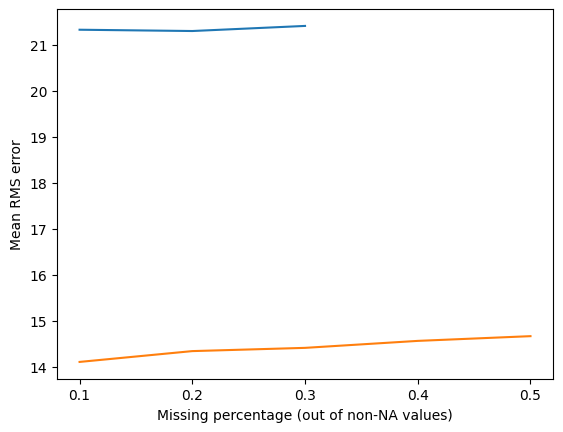

In [5]:
fig, ax = plt.subplots()
plt.plot(pcts, knn_scores, pcts, temp_scores)
plt.xlabel("Missing percentage (out of non-NA values)")
plt.xticks(pcts)
plt.ylabel("Mean RMS error")

np.float64(21.329557002050255)

In [13]:
rows, cols, true_values = select_true_points(X_test[0], 0.10, 123)
np.sum(np.ravel(X_test[0][rows, cols]) == true_values)

np.int64(10801)

### KNNImputer CV (with blocks)

In [ ]:
# Stacking of training cases for KNN imputer:
# concatenate 5 successive rows to one feature vector (5 * 180 = 900 features)
trains = []
for train in X_train:
    train_stacked = sliding_window_view(train, window_shape=(5,180)).reshape(-1, 5 * train.shape[1])   # ChatGPT solution
    trains.append(train_stacked)

X_train_stacked = np.vstack(trains)

In [ ]:
import logging
import sys
filehandler = logging.FileHandler(filename="./logs/cv_results.log", encoding="utf-8")
streamhandler = logging.StreamHandler(sys.stdout)
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(message)s', datefmt='%m/%d/%Y %H:%M:%S', handlers=[filehandler, streamhandler], force=True)

def form_test_matrices_blocks(model: KNNImputer, X_test: np.ndarray,
                       y_test: np.ndarray, n_samples=10, sample_loc=120) -> list:
    true = X_test[sample_loc:sample_loc+n_samples]
    test = y_test[sample_loc:sample_loc+n_samples]
    reduced = np.where(np.isfinite(test), true, np.nan)
    
    reduced_reshaped = reduced.reshape((2, 900))
    pred_full_reshaped = model.transform(reduced_reshaped)
    pred_full = pred_full_reshaped.reshape((10, 180))

    pred = np.where((np.isnan(reduced)
                    & np.isfinite(true)
                    & np.meshgrid(np.isfinite(reduced).any(axis=1), np.arange(0, reduced.shape[1]),
                                  indexing="ij")[0]),
                    pred_full, np.nan)
    target = np.where(np.isfinite(pred), true, np.nan)

    return [true, reduced, pred_full, pred, target]

# Model selection CV
neighbors = np.arange(0, 31, 5)
neighbors[0] = 1
#weights = ["distance", "uniform"]      10.2. no noticeable difference between these
n_splits = 3
n_events = 20
n_samples = 10
sample_loc = 120 # onset is located at two hours after start of the window

# Cross validation: shift train-test split by one 3 times (a sort of 3-fold CV),
# but test only 10 samples in each event (after onset) and only 20 events in each fold

for n in neighbors:
    model = KNNImputer(n_neighbors=n, weights="distance", keep_empty_features=True)
    
    for shift in range(n_splits):
        logging.info(f"KNN neighbors={n}, split {shift}")
        result_df = pd.DataFrame()
        (X_train, X_test, y_train, y_test,
        I_train, I_test, meta_train, meta_test) = make_train_test(hist_arr, reduced_hist_arr,
                                                                intensity_arr, metadata_arr,
                                                                n=n_splits, shift=shift)
        trains = []
        for train in X_train:
            train_stacked = sliding_window_view(train, window_shape=(5, train.shape[1])).reshape(-1, 5 * train.shape[1])   # ChatGPT solution
            trains.append(train_stacked)

        X_train_stacked = np.vstack(trains)
        model.fit(X_train_stacked)
        scores = []
        for j in range(20):
            res = form_test_matrices_blocks(model, X_test[j], y_test[j])
            # plot_results(model, res, "rmse", I_test[j], sc=wind, cov_sc=solo,
            #              save_path=plot_path / "knnimputer" / "crossvalidation" / f"knn_{n}_{w}_split_{shift}_results_{j}.png")
            
            # Score on n_samples samples during main event
            score = calculate_scores(res[3],
                                     res[4], "rmse")
            result_df = save_results(model, res, meta_test[j], "rmse", Path(f"./knn_{n}_split_{shift}_results.csv"))
            scores.append(score)
            logging.info(f"Score for test event {j}: {score}")

        clear_output()
        logging.info(f"KNN neighbors={n}: CV score on fold {shift}={np.mean(scores):.4f}")


02/10/2026 12:46:53 KNN neighbors=15, weights=uniform: CV score on fold 2=2407.7693


In [ ]:
for s, n in product(range(n_splits), neighbors):
    df = pd.read_csv(Path(f"./knn_{n}_split_{s}_results.csv"))
    print(f"KNN neighbors={n}:\t CV score (RMSE) on fold {s} = {df.score.mean():.4f}")
    if n == 30:
        print("\n")

KNN neighbors=1, weights=distance:	 CV score (RMSE) on fold 0 = 147.0493
KNN neighbors=1, weights=uniform:	 CV score (RMSE) on fold 0 = 147.0493
KNN neighbors=5, weights=distance:	 CV score (RMSE) on fold 0 = 135.1752
KNN neighbors=5, weights=uniform:	 CV score (RMSE) on fold 0 = 135.3559
KNN neighbors=10, weights=distance:	 CV score (RMSE) on fold 0 = 129.3200
KNN neighbors=10, weights=uniform:	 CV score (RMSE) on fold 0 = 129.3255
KNN neighbors=15, weights=distance:	 CV score (RMSE) on fold 0 = 126.7913
KNN neighbors=15, weights=uniform:	 CV score (RMSE) on fold 0 = 126.8208


KNN neighbors=1, weights=distance:	 CV score (RMSE) on fold 1 = 201.1066
KNN neighbors=1, weights=uniform:	 CV score (RMSE) on fold 1 = 201.1066
KNN neighbors=5, weights=distance:	 CV score (RMSE) on fold 1 = 172.4163
KNN neighbors=5, weights=uniform:	 CV score (RMSE) on fold 1 = 180.1932
KNN neighbors=10, weights=distance:	 CV score (RMSE) on fold 1 = 175.0251
KNN neighbors=10, weights=uniform:	 CV score (RMSE

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_features=32)

# X = true, y = reduced. Train model with y as input, X as output
X_trains = []
y_trains = []
for X, y in zip(X_train, y_train):
    X_stacked = sliding_window_view(X, window_shape=(5,180)).reshape(-1, 5 * train.shape[1])
    y_stacked = sliding_window_view(y, window_shape=(5,180)).reshape(-1, 5 * train.shape[1])   # ChatGPT solution
    y_trains.append(y_stacked)
    X_trains.append(X_stacked)

X_train_stacked = np.vstack(X_trains)
y_train_stacked = np.vstack(y_trains)

In [3]:
import numpy as np

x = np.array([1, 2, 3, np.nan])
np.flatnonzero(x)

array([0, 1, 2, 3])

In [2]:
import numpy as np
from sklearn.impute import KNNImputer
nan = np.nan
X = [[1, 2, nan], [3, 4, 3], [nan, 6, 5], [8, 8, 7]]
imputer = KNNImputer(n_neighbors=2, weights="uniform")
X_imp = imputer.fit_transform(X)
print(X)

[[1, 2, nan], [3, 4, 3], [nan, 6, 5], [8, 8, 7]]
